# Simulating FRB Populations from a Radio Survey

This notebook demonstrates how to use the `astropath.simulations.generate_frbs` module to simulate the population of FRBs and corresponding host galaxies that we expect to detect for different FRB surveys, including CHIME, DSA, and CRAFT ICS. Different surveys have different selection functions, leading to different redshift, DM, and host apparent magnitude distributions.

The result is a `pandas.DataFrame` with generated FRB properties:
- `DMeg`: Extragalactic dispersion measure ($\rm pc\,cm^{-3}$)
- `z`: Redshift
- `M_r`: Host galaxy absolute r-band magnitude
- `m_r`: Host galaxy apparent r-band magnitude

For a full description of the simulation procedure, see Section 3.1 of Andersen+26.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('text', usetex=False)
import matplotlib
import numpy as np
import pandas as pd

In [98]:
from astropath.simulations import generate_frbs, SURVEY_GRIDS
from importlib.resources import files
import scipy.stats as stats

## Available Surveys

The module supports several FRB surveys, each with its own `P(z,DM_EG)` grid that captures the selection effects and sensitivity of that instrument. Given a survey name, the corresponding `P(z,DM_EG)` grid is grabbed from the `FRB` repository (see [frb.dm.prob_dmz](https://github.com/FRBs/FRB/blob/996fcda9b0b22431e3171208b4c8e1cf2798e823/frb/dm/prob_dmz.py#L4)).

In [8]:
print("Available surveys:")
for survey in SURVEY_GRIDS.keys():
    print(f"  - {survey}")

Available surveys:
  - CHIME
  - DSA
  - ASKAP
  - CRAFT
  - CRAFT_ICS_1300
  - CRAFT_ICS_892
  - CRAFT_ICS_1632
  - Parkes
  - FAST


## Generate FRBs: from a z-DM Grid

In the most basic use-case, the distribution of simulated FRB DMs and redshifts is randomly sampled from the entire `P(z,DM_EG)` grid. After sampling for `DM_EG` and `z`, `generate_frbs` then samples an absolute r-band magnitude `M_r` for each simulated host from the intrinsic luminosity distribution of FRB host galaxies that have been confidently associated thus-far (see the [Lz_host_data.csv](https://github.com/FRBs/astropath/tree/main/astropath/data/frb_surveys) file in `FRB` and Section 3.1 of Andersen+26). This magnitude is then scaled by the distance modulus of the simulated `z` to derive an apparent magnitude `m_r` for each simulated hosts.

The user can input the number of FRBs to simulate.

In [63]:
# Generate 1000 CHIME FRBs with a fixed seed for reproducibility
n_frbs = 1000
df_chime = generate_frbs(n_frbs, 'CHIME', seed=42)

print(f"Generated {len(df_chime)} CHIME FRBs")
df_chime.head(10)

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Generated 1000 CHIME FRBs


,DMeg,z,M_r,m_r
0,445.0,0.25,-21.681575,18.889973
1,1175.0,1.38,-20.278551,24.743318
2,710.0,0.63,-18.475358,24.456045
3,585.0,0.45,-19.330649,22.723243
4,215.0,0.11,-18.918085,19.690382
5,215.0,0.11,-19.709010,18.899457
6,225.0,0.05,-19.538448,17.269064
7,850.0,0.94,-18.647786,25.346529
8,1225.0,0.45,-21.433325,20.620566
9,930.0,0.59,-20.513442,22.245471


## Comparing Different Surveys

Here we vizualize FRBs simulated from CHIME, the DSA, and CRAFT ICS.

In [64]:
# Generate FRBs for three major surveys
n_frbs = 10000
seed = 42

df_chime = generate_frbs(n_frbs, 'CHIME', seed=seed)
df_dsa = generate_frbs(n_frbs, 'DSA', seed=seed)
df_craft = generate_frbs(n_frbs, 'CRAFT', seed=seed)

surveys = {
    'CHIME': df_chime,
    'DSA': df_dsa,
    'CRAFT': df_craft
}

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/DSA_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CRAFT_class_I_and_II_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes


### Redshift Distributions

Text(0.45, 1.2, 'Redshift Distributions by Survey')

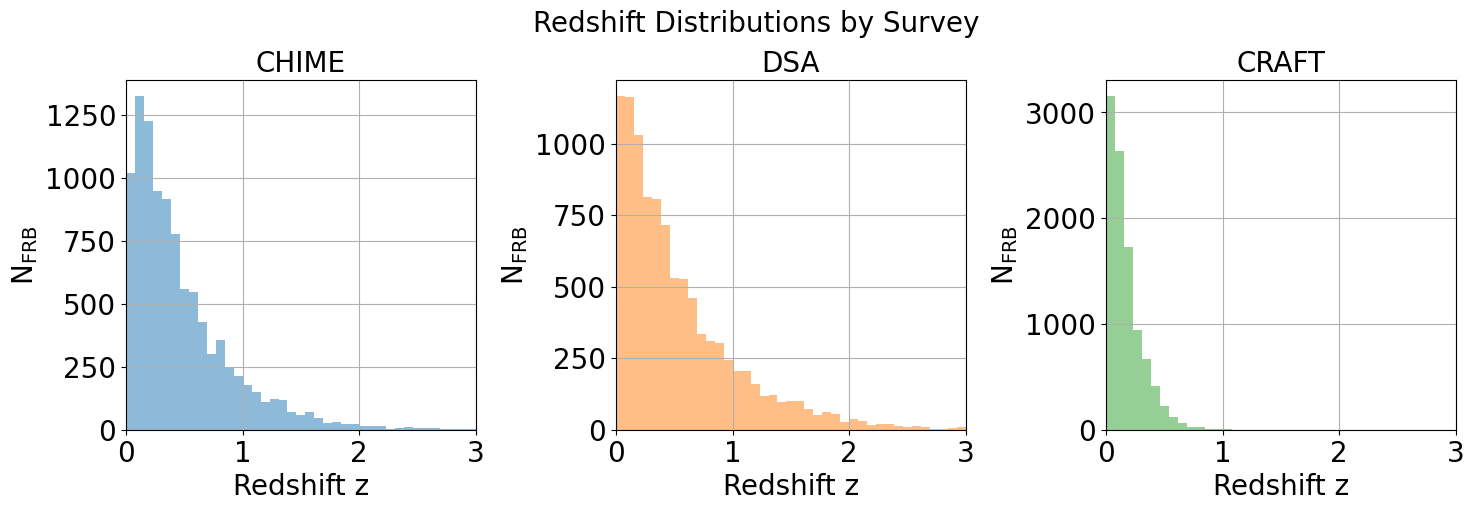

In [50]:
fig = plt.figure(figsize=(14,3.5))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.25
sep_w = 0.1
ax_chime = (0., 0., width, 1.)
ax_dsa = (width+sep_w, 0., width, 1.)
ax_craft = (2*(width+sep_w), 0., width, 1.)
axes = [plt.axes(ax_chime), plt.axes(ax_dsa), plt.axes(ax_craft)]
bins = np.linspace(0., 3., 40)

for ax, (name, df), color in zip(axes, surveys.items(), cycle):
    ax.hist(df['z'], bins=bins, alpha=0.5, color=color, density=False)
    ax.set_xlabel('Redshift z')
    ax.set_ylabel(r'$\rm N_{FRB}$')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 3)
    ax.grid()

plt.suptitle('Redshift Distributions by Survey', fontsize=20, x=0.45, y=1.2)

### DM Distributions

Text(0.45, 1.2, 'DM Distributions by Survey')

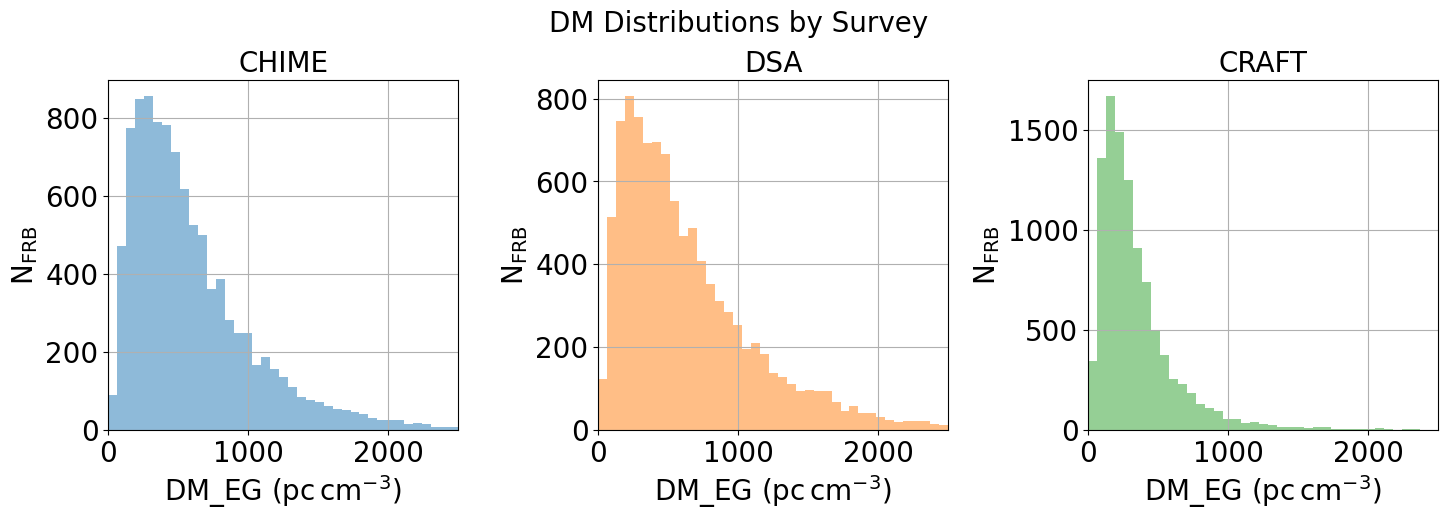

In [51]:
fig = plt.figure(figsize=(14,3.5))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.25
sep_w = 0.1
ax_chime = (0., 0., width, 1.)
ax_dsa = (width+sep_w, 0., width, 1.)
ax_craft = (2*(width+sep_w), 0., width, 1.)
axes = [plt.axes(ax_chime), plt.axes(ax_dsa), plt.axes(ax_craft)]
bins = np.linspace(0., 2500., 40)

for ax, (name, df), color in zip(axes, surveys.items(), cycle):
    ax.hist(df['DMeg'], bins=bins, alpha=0.5, color=color, density=False)
    ax.set_xlabel(r'DM_EG ($\rm pc\,cm^{-3}$)')
    ax.set_ylabel(r'$\rm N_{FRB}$')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 2500)
    ax.grid()

plt.suptitle('DM Distributions by Survey', fontsize=20, x=0.45, y=1.2)

### DM vs Redshift

Text(0.45, 1.2, 'DM vs Redshift by Survey')

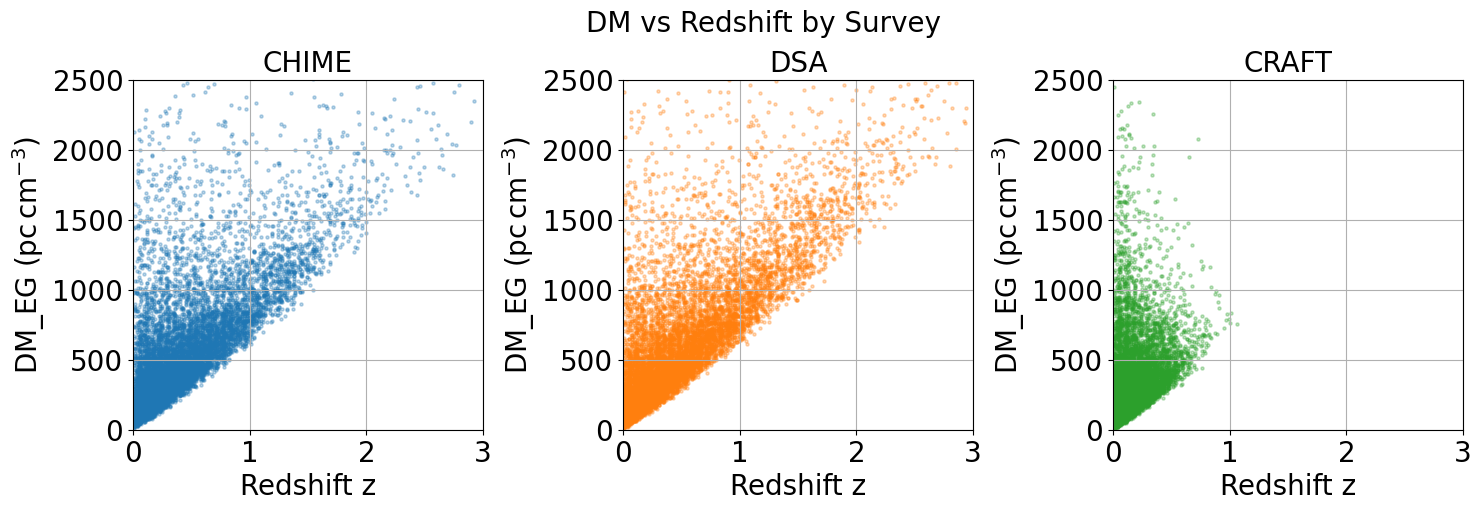

In [52]:
fig = plt.figure(figsize=(14,3.5))

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.25
sep_w = 0.1
ax_chime = (0., 0., width, 1.)
ax_dsa = (width+sep_w, 0., width, 1.)
ax_craft = (2*(width+sep_w), 0., width, 1.)
axes = [plt.axes(ax_chime), plt.axes(ax_dsa), plt.axes(ax_craft)]
bins = np.linspace(0., 2500., 40)

for ax, (name, df), color in zip(axes, surveys.items(), cycle):
    ax.scatter(df['z'], df['DMeg'], alpha=0.3, s=5, color=color)
    ax.set_ylabel(r'DM_EG ($\rm pc\,cm^{-3}$)')
    ax.set_xlabel('Redshift z')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 2500)
    ax.grid()

plt.suptitle('DM vs Redshift by Survey', fontsize=20, x=0.45, y=1.2)

### Apparent Magnitude Distributions

The apparent magnitude of the host galaxy depends on both the absolute magnitude (M_r) and the redshift.

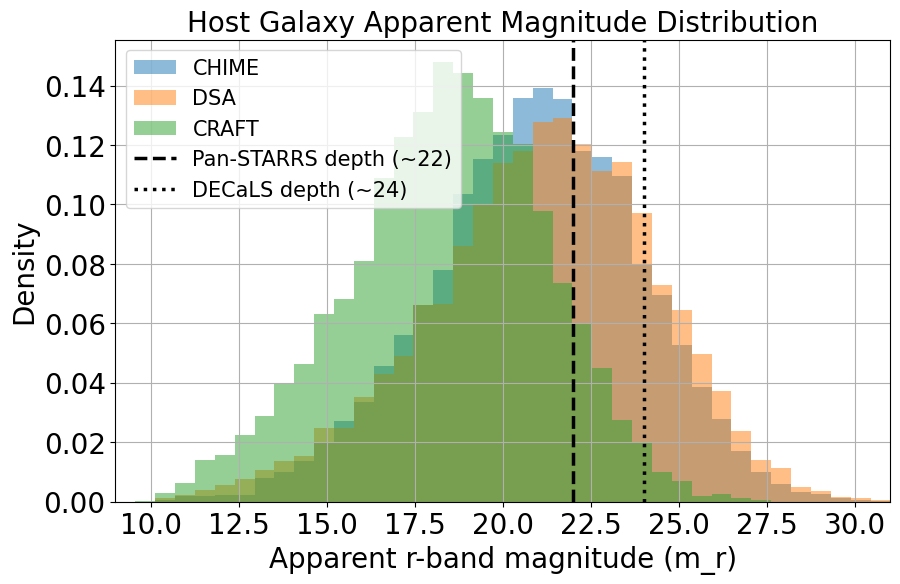

In [62]:
fig = plt.figure(figsize=(10,6))
ax = plt.gca()

bins = np.linspace(9, 31, 40)
for (name, df), color in zip(surveys.items(), cycle):
    ax.hist(df['m_r'], bins=bins, alpha=0.5, color=color, label=name, density=True)

# Add typical survey depth limits
ax.axvline(22, color='black', linestyle='--', linewidth=2.5, label='Pan-STARRS depth (~22)')
ax.axvline(24, color='black', linestyle=':', linewidth=2.5, label='DECaLS depth (~24)')

ax.set_xlabel('Apparent r-band magnitude (m_r)')
ax.set_ylabel('Density')
ax.set_title('Host Galaxy Apparent Magnitude Distribution')
ax.legend()
ax.set_xlim(9, 31)
plt.grid()

## Generate FRBs: from an Observed DM Catalog

If you have observed extragalactic DM values from a specific subsample of bursts detected by a survey, `generate_frbs` also contains an option to simulate `DM_EG` values from this subsample. Kernel density estimation (KDE) is used to generate a continuous probability density from the discrete distribution of observed `DM_EG`. This KDE is used to sample `DM_EG`, and `P(z,DM_EG)` is used to then sample corresponding redshifts for those DMs.

This functionality is useful when you want to simulate FRBs that match a certain subsample that is not captured by the full `P(z,DM_EG)` grid. For example, in Andersen+26, we use this technique to simulate the subsample of CHIME-detected FRBs that have a S/N ratio high enough (`S/N > 12`) to trigger the search pipeline to save raw voltage (baseband) data.

In [95]:
# Example: DMs from CHIME/FRB Catalog 1 with S/N > 12
fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]
print(f"Observed DSA DMs: N={len(chime_observed_dms_eg)}, median={np.median(chime_observed_dms_eg):.0f}" + r"$\rm pc cm^{-3}$")

Observed DSA DMs: N=402, median=411$\rm pc cm^{-3}$


In [99]:
# Calculate KDE for plotting purposes
kernel = stats.gaussian_kde(chime_observed_dms_eg)#, bw_method=0.6)
dms = np.linspace(0., 3000, 500)
chime_observed_dms_eg_kde = kernel(dms)

In [96]:
# Generate FRBs using the observed DM distribution
df_chime_from_catalog = generate_frbs(10000, 'CHIME', dm_catalog=chime_observed_dms_eg, seed=42)

# Compare with default sampling
df_chime_default = generate_frbs(10000, 'CHIME', seed=42)

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes


Text(0.5, 1.15, 'Effect of Using Observed DM Catalog')

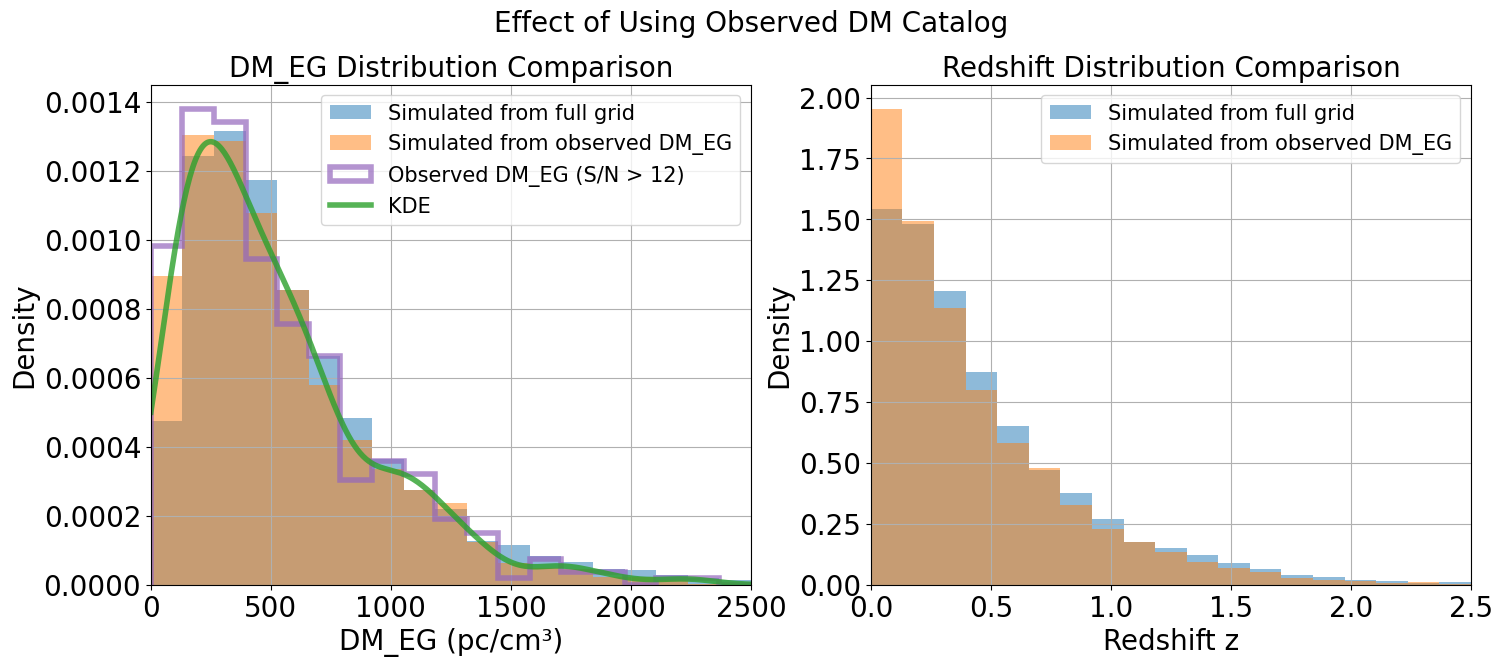

In [127]:
fig = plt.figure(figsize=(12,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.1
ax_dms = (0., 0., width, 1.)
ax_redshifts = (width+sep_w, 0., width, 1.)

# DM comparison
ax = plt.axes(ax_dms)
bins = np.linspace(0,2500,20)
ax.hist(df_chime_default['DMeg'], color=cycle[0], bins=bins, alpha=0.5, label='Simulated from full grid', density=True)
ax.hist(df_chime_from_catalog['DMeg'], color=cycle[1], bins=bins, alpha=0.5, label='Simulated from observed DM_EG', density=True)
ax.hist(chime_observed_dms_eg, bins=bins, alpha=0.7, histtype='step', linewidth=4, 
        color=cycle[4], label='Observed DM_EG (S/N > 12)', density=True)
plt.plot(dms, chime_observed_dms_eg_kde, color=cycle[2], alpha=0.8, lw=4, label='KDE')
ax.set_xlabel('DM_EG (pc/cm³)')
ax.set_ylabel('Density')
ax.set_title('DM_EG Distribution Comparison')
plt.xlim([0,2500])
ax.legend()
ax.grid()

# Redshift comparison
ax = plt.axes(ax_redshifts)
bins = np.linspace(0,2.5,20)
ax.hist(df_chime_default['z'], color=cycle[0], bins=bins, alpha=0.5, label='Simulated from full grid',  density=True)
ax.hist(df_chime_from_catalog['z'], color=cycle[1], bins=bins, alpha=0.5, label='Simulated from observed DM_EG', density=True)
ax.set_xlabel('Redshift z')
ax.set_ylabel('Density')
plt.xlim([0,2.5])
ax.set_title('Redshift Distribution Comparison')
ax.legend()
ax.grid()

plt.suptitle('Effect of Using Observed DM Catalog', fontsize=20, y=1.15)

## Using a Custom Cosmology

By default, the module uses Planck18 cosmology. You can specify a different cosmology for the distance modulus calculations.

In [125]:
from astropy.cosmology import WMAP9, Planck18

# Compare apparent magnitudes with different cosmologies
df_planck = generate_frbs(1000, 'CHIME', cosmo=Planck18, seed=42)
df_wmap = generate_frbs(1000, 'CHIME', cosmo=WMAP9, seed=42)

# The DM, z, and M_r will be the same, but m_r will differ slightly
print("Comparison of apparent magnitudes with different cosmologies:")
print(f"  Planck18 median m_r: {df_planck['m_r'].median():.3f}")
print(f"  WMAP9 median m_r:    {df_wmap['m_r'].median():.3f}")
print(f"  Difference:          {(df_planck['m_r'].median() - df_wmap['m_r'].median()):.4f} mag")

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Comparison of apparent magnitudes with different cosmologies:
  Planck18 median m_r: 21.015
  WMAP9 median m_r:    20.980
  Difference:          0.0346 mag


## Saving Generated FRBs

You can save the generated FRB population to various formats for use in the subsequent simulation steps.

In [126]:
# Generate a sample population
df_sample = generate_frbs(10000, 'CHIME', seed=42)

# Uncomment to save to different formats
# df_sample.to_csv('simulated_chime_frbs.csv', index=False)
# df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)

print("Example of saving to CSV:")
print("  df_sample.to_csv('simulated_chime_frbs.csv', index=False)")
print("\nExample of saving to Parquet:")
print("  df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)")

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Example of saving to CSV:
  df_sample.to_csv('simulated_chime_frbs.csv', index=False)

Example of saving to Parquet:
  df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)
